In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from torch.distributions import Categorical
import matplotlib.pyplot as plt

In [3]:
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"State dim: {state_dim}")
print(f"Action dim: {action_dim}")
print(f"Device: {device}")

State dim: 4
Action dim: 2
Device: cuda


In [4]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        logits = self.fc3(x)
        return torch.softmax(logits, dim=-1)

class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def moving_average(data, window=100):
    return [np.mean(data[max(0, i-window):i+1]) for i in range(len(data))]

def evaluate_policy(env_name, policy, num_episodes=20, greedy=True, seed=42):
    env = gym.make(env_name)
    total_rewards = []
    for ep in range(num_episodes):
        torch.manual_seed(seed + ep)
        state, _ = env.reset(seed=seed + ep)
        ep_reward = 0
        done = False
        while not done:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                probs = policy(state_t)
            if greedy:
                action = torch.argmax(probs, dim=-1).item()
            else:
                action = Categorical(probs).sample().item()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
        total_rewards.append(ep_reward)
    env.close()
    print(f"Mean: {np.mean(total_rewards):.1f}, Std: {np.std(total_rewards):.1f}")
    return total_rewards

In [ ]:
def collect_trajectories(env, policy, value_net, num_steps=2048, gamma=0.99, lamb=0.95):
    states, actions, rewards, values, dones, log_probs = [], [], [], [], [], []

    state, _ = env.reset()
    for _ in range(num_steps):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            probs = policy(state_t)
            value = value_net(state_t)

        dist = Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        states.append(state)
        actions.append(action.item())
        rewards.append(reward)
        values.append(value.item())
        dones.append(done)
        log_probs.append(log_prob.item())

        state = next_state
        if done:
            state, _ = env.reset()

    # Boostrap value for the final state (needed for GAE at the trajectory boundary)
    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
    with torch.no_grad():
        next_value = value_net(state_t).item()
    values.append(next_value)

    # GAE computation
    advantages = np.zeros(len(rewards), dtype=np.float32)
    gae = 0
    for t in reversed(range(len(rewards))):
        mask = 1.0 - dones[t] # zero out boostrap across episode boundaries
        delta = rewards[t] + gamma * values[t+1] * mask- values[t]
        gae = delta + gamma * lamb * mask * gae
        advantages[t] = gae

    returns = advantages + np.array(values[:-1], dtype=np.float32) # for value function target

    # Normalize advantages (stabilizes training)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    return (
        torch.FloatTensor(np.array(states)).to(device),
        torch.LongTensor(actions).to(device),
        torch.FloatTensor(log_probs).to(device),
        torch.FloatTensor(returns).to(device),
        torch.FloatTensor(advantages).to(device),
    )

In [7]:
def get_log_probs(policy, states, actions):
    probs = policy(states)
    dist = Categorical(probs)
    return dist.log_prob(actions), probs

def surrogate_loss(policy, states, actions, old_log_probs, advantages):
    """
    TRPO Surrogate Objective (to be maximized):
        L(theta) = E[ (pi_theta(a|s) / pi_theta_old(a|s)) * A(s,a) ]
        pi_theta(a|s) / pi_theta_old(a|s) = exp( log(pi_theta(a|s)) - log(pi_theta_old(a|s)) )
    """
    new_log_probs, _ = get_log_probs(policy, states, actions)
    ratio = torch.exp(new_log_probs - old_log_probs)
    return (ratio * advantages).mean()

def compute_kl(policy, old_probs, states):
    """
    Mean KL divergence between old policy (fixed) and current policy,
    averaged over the batch of states.

    D_KL( pi_old || pi_theta ) = sum_a [ pi_old(a|s) * log( pi_old(a|s) / pi_theta(a|s) ) ]
    """
    new_probs = policy(states)
    kl = (old_probs * (torch.log(old_probs + 1e-10) - torch.log(new_probs + 1e-10))).sum(dim=-1)
    return kl.mean()

In [8]:
def get_flat_params(model):
    """Flatten all parameters of a model into a single 1D tensor."""
    return torch.cat([p.data.view(-1) for p in model.parameters()])


def set_flat_params(model, flat_params):
    """Load a flattened 1D tensor back into a model's parameters"""
    idx = 0
    for p in model.parameters():
        numel = p.numel() # number of elements in p
        p.data.copy_(flat_params[idx:idx+numel].view(p.shape))
        idx += numel


def get_flat_grad(loss, model, retain_graph=False, create_graph=False):
    """
    Compute gradient of loss w.r.t. model parameters, flattened into 1D tensor.
    create_graph=True is needed when we need to differentiate through this 
    gradient again (double backward, used in Fisher-vector product).
    """
    grads = torch.autograd.grad(loss, model.parameters(),
                                 retain_graph=retain_graph, create_graph=create_graph)
    return torch.cat([g.contiguous().view(-1) for g in grads])

In [9]:
def fisher_vector_product(policy, states, old_probs, v, damping=0.1):
    """
    Compute F @ v without ever constructing F explicitly.

    F is the Hessian of the mean KL divergence w.r.t. policy parameters,
    evaluated at the current (old) policy.

    Steps:
        1. Compute KL divergence (old policy vs current policy — 
           at this point they're the same, so KL=0, but its gradient 
           w.r.t. theta is still well-defined and nonzero for 2nd derivative)
        2. Get its gradient (create_graph=True so we can differentiate again)
        3. Compute (gradient . v) — a scalar
        4. Differentiate that scalar again w.r.t. theta → this gives F @ v

    damping: small value added to diagonal for numerical stability 
             (F can be near-singular / positive semi-definite only)
    """
    kl = compute_kl(policy, old_probs, states)

    grad_kl = get_flat_grad(kl, policy, create_graph=True, retain_graph=True)
    grad_kl_v = (grad_kl * v).sum()

    fisher_vector = get_flat_grad(grad_kl_v, policy, retain_graph=True)

    return fisher_vector + damping * v   # damping for numerical stability

In [10]:
def conjugate_gradient(policy, states, old_probs, g, num_iters=10, tol=1e-10):
    """
    Solv F @ x = g for x, using only Fisher-vector products (never forming F).

    g: gradient of surrogate loss (flattened)
    returns: x = F^-1 @ g (the natural gradient direction)
    """
    x = torch.zeros_like(g)
    r = g.clone() # residual
    p = g.clone() # search direction
    rs_old = torch.dot(r, r)

    for i in range(num_iters):
        Fp = fisher_vector_product(policy, states, old_probs, p)
        alpha = rs_old / (torch.dot(p, Fp) + 1e-10)

        x += alpha * p
        r -= alpha * Fp

        rs_new = torch.dot(r, r)
        if rs_new < tol:
            break

        beta = rs_new / rs_old
        p = r + beta * p
        rs_old = rs_new

    return x

In [21]:
def line_search(policy, states, actions, old_log_probs, old_probs, advantages,
                fullstep, expected_improve, max_kl=0.01,
                max_backtracks=10, backtrack_coeff=0.5):
    """
    Backtracking line search:
        Try the full natural gradient step first. If it doesn't satisfy
        (a) KL constraint and (b) actual improvement, shrink the step and retry.

    fullstep: the proposed parameter update (already ascaled to satisfy KL in theory)
    expected_improve: predicted improvement from the linear approximation (g * fullstep)
    """
    old_params = get_flat_params(policy)
    old_loss = surrogate_loss(policy, states, actions, old_log_probs, advantages).item()

    for i in range(max_backtracks):
        step_frac = backtrack_coeff ** i
        new_params = old_params + step_frac * fullstep
        set_flat_params(policy, new_params)

        with torch.no_grad():
            new_loss = surrogate_loss(policy, states, actions, old_log_probs, advantages).item()
            kl = compute_kl(policy, old_probs, states).item()

        actual_improve = new_loss - old_loss
        expected = expected_improve * step_frac

        if kl <= max_kl and actual_improve > 0:
            print(f"  Line search accepted at backtrack {i} "
                  f"(step_frac={step_frac:.4f}, KL={kl:.5f}, improve={actual_improve:.5f})")
            return True, kl, i

        # revert and try smaller step
        set_flat_params(policy, old_params)

    print("  Line search failed, no update applied")
    return False, None, max_backtracks

In [22]:
def update_trpo(policy, value_net, value_optimizer,
                states, actions, old_log_probs, returns, advantages,
                max_kl=0.01, cg_iters=10, damping=0.1):
    """
    TRPO update step:
        1. Compute surrogate loss gradient, g.
        2. Solve F @ x = g via conjugate gradient -> natural gradient direction
        3. Scale step to satisfy KL constraint.
        4. Line search to confirm actual improvement + KL constraint
        5. Separately update the value network (ordinary gradient descent)
    """
    old_probs = policy(states).detach()

    # 1. Surrogate loss gradient
    loss = surrogate_loss(policy, states, actions, old_log_probs, advantages)
    g = get_flat_grad(loss, policy, retain_graph=True)

    if g.norm() < 1e-8:
        print("  Gradient too small, skipping the update")
        return loss.item(), 0.0, 0.0, 0

    # 2. Natural gradient direction via conjugate gradient
    step_dir = conjugate_gradient(policy, states, old_probs, g, num_iters=cg_iters)

    # 3. Scale step to satisfy KL constraint: sqrt(2*delta / (x^T Fx)) * x
    Fx = fisher_vector_product(policy, states, old_probs, step_dir, damping=damping)
    shs = torch.dot(step_dir, Fx) # x^T Fx
    step_size = torch.sqrt(2 * max_kl / (shs + 1e-10))
    fullstep = step_size * step_dir

    expected_improve = torch.dot(g, fullstep).item()

    # 4. Line search
    success, kl, num_backtracks = line_search(
        policy, states, actions, old_log_probs, old_probs, advantages,
        fullstep, expected_improve, max_kl=max_kl)
    
    # 5. Value network update (ordinary gradient descent, separate from policy)
    value_pred = value_net(states).squeeze(-1)
    value_loss = nn.functional.mse_loss(value_pred, returns)

    value_optimizer.zero_grad()
    value_loss.backward()
    value_optimizer.step()

    kl_value = kl if kl is not None else 0.0  
    return loss.item(), value_loss.item(), kl_value, num_backtracks

In [25]:
def train(env, policy, value_net, value_optimizer,
          num_iterations=200, num_steps=2048, gamma=0.99, lamb=0.95,
          max_kl=0.01, cg_iters=10, damping=0.1, print_every=10):
    """
    Full TRPO training loop.

    Each iteration:
        1. Collect a batch of num_steps transitions using the current policy
        2. Run one TRPO update (natural gradient + line search) on the policy
        3. Update the value network via ordinary gradient descent
    """
    iteration_rewards = [] 
    surrogate_losses = []
    value_losses = []
    kls = []
    backtracks = []

    for iteration in range(num_iterations):
        states, actions, old_log_probs, returns, advantages = collect_trajectories(
            env, policy, value_net, num_steps=num_steps, gamma=gamma, lamb=lamb
        )

        loss, v_loss, kl, num_backtracks = update_trpo(
            policy, value_net, value_optimizer,
            states, actions, old_log_probs, returns, advantages,
            max_kl=max_kl, cg_iters=cg_iters, damping=damping
        )
        surrogate_losses.append(loss)
        value_losses.append(v_loss)
        kls.append(kl)
        backtracks.append(num_backtracks)

        # Estimate mean episode reward within this batch (rough proxy — 
        # since collect_trajectories doesn't track full episode boundaries cleanly here,
        # we instead evaluate the policy directly for a cleaner signal)
        eval_rewards = evaluate_policy('CartPole-v1', policy, num_episodes=5, greedy=True, seed=iteration)
        mean_reward = np.mean(eval_rewards)
        iteration_rewards.append(mean_reward)

        if (iteration + 1) % print_every == 0:
            print(f"Iteration {iteration+1}/{num_iterations} | "
                  f"Eval reward: {mean_reward:.1f} | "
                  f"Surrogate loss: {loss:.4f} | Value loss: {v_loss:.4f} | "
                  f"KL: {kl:.5f} | Backtracks: {num_backtracks}")

        if len(iteration_rewards) >= 10 and np.mean(iteration_rewards[-10:]) >= 195:
            print(f"\nSolved at iteration {iteration+1}! "
                  f"Avg reward (last 10 iters): {np.mean(iteration_rewards[-10:]):.1f}")
            break

    return iteration_rewards, surrogate_losses, value_losses, kls, backtracks

In [26]:
set_seed(42)
env.reset(seed=42)

policy    = PolicyNetwork(state_dim, action_dim).to(device)
value_net = ValueNetwork(state_dim).to(device)
value_optimizer = optim.Adam(value_net.parameters(), lr=1e-3)

iteration_rewards, surrogate_losses, value_losses, kls, backtracks = train(
    env, policy, value_net, value_optimizer,
    num_iterations=200, num_steps=2048
)

  Line search accepted at backtrack 0 (step_frac=1.0000, KL=0.00465, improve=0.01749)
Mean: 56.6, Std: 13.3
  Line search accepted at backtrack 0 (step_frac=1.0000, KL=0.00580, improve=0.01585)
Mean: 225.4, Std: 95.7
  Line search accepted at backtrack 0 (step_frac=1.0000, KL=0.00815, improve=0.02438)
Mean: 275.0, Std: 148.2
  Line search accepted at backtrack 0 (step_frac=1.0000, KL=0.00636, improve=0.02529)
Mean: 386.0, Std: 130.8
  Line search accepted at backtrack 0 (step_frac=1.0000, KL=0.00716, improve=0.02397)
Mean: 429.6, Std: 88.0
  Line search accepted at backtrack 0 (step_frac=1.0000, KL=0.00633, improve=0.01963)
Mean: 500.0, Std: 0.0
  Line search accepted at backtrack 0 (step_frac=1.0000, KL=0.00654, improve=0.02094)
Mean: 479.4, Std: 41.2
  Line search accepted at backtrack 0 (step_frac=1.0000, KL=0.00418, improve=0.01767)
Mean: 476.0, Std: 48.0
  Line search accepted at backtrack 0 (step_frac=1.0000, KL=0.00381, improve=0.01913)
Mean: 451.8, Std: 60.2
  Line search accep

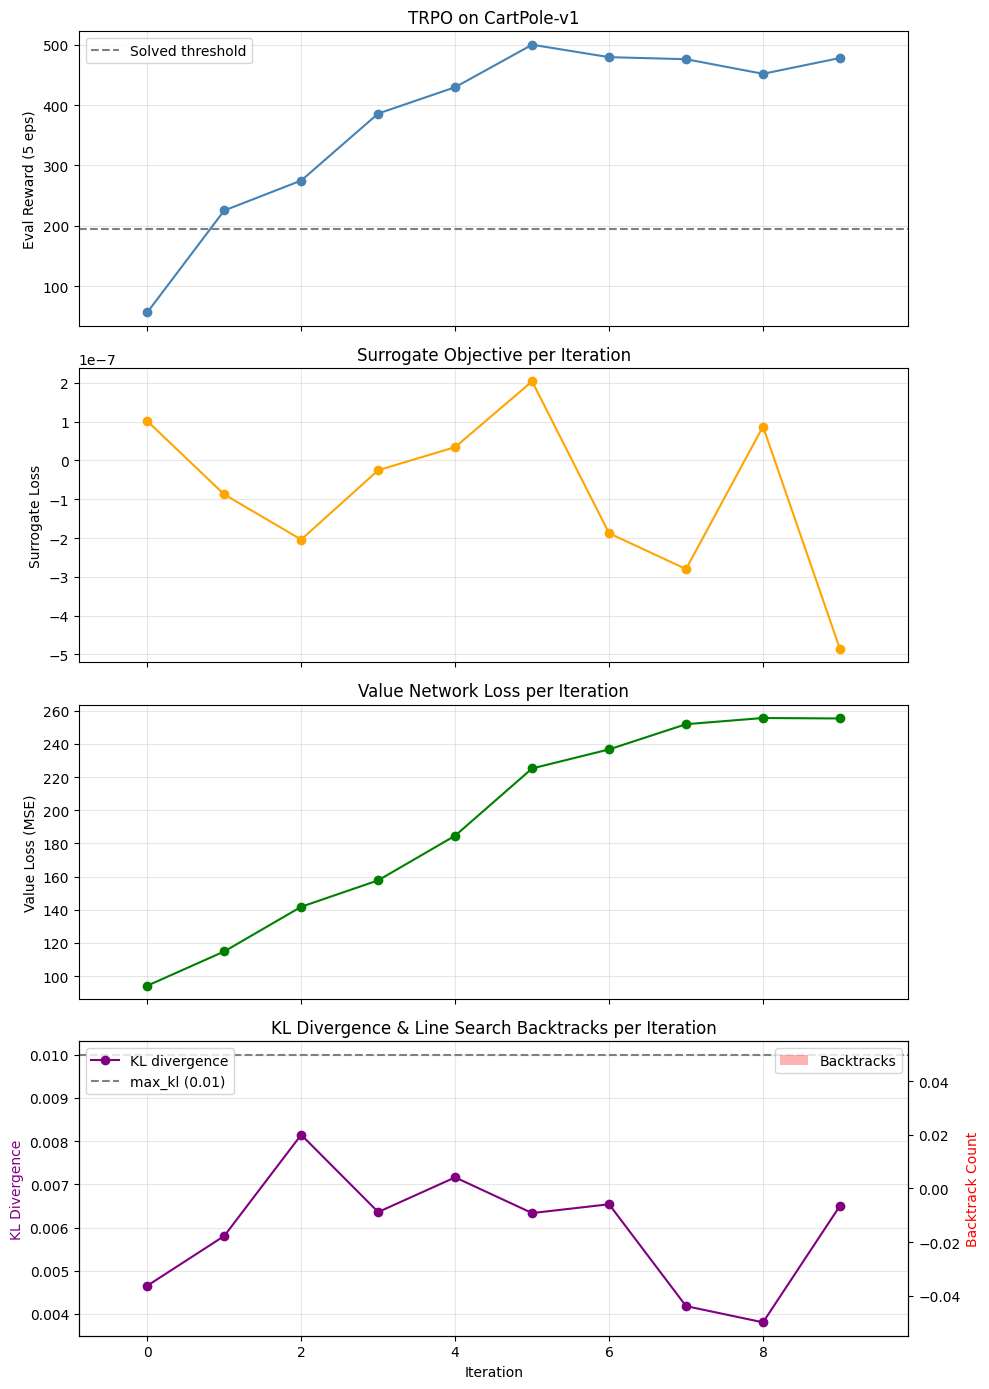

In [27]:
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

axes[0].plot(iteration_rewards, marker='o', color='steelblue')
axes[0].axhline(y=195, color='gray', linestyle='--', label='Solved threshold')
axes[0].set_ylabel('Eval Reward (5 eps)')
axes[0].set_title('TRPO on CartPole-v1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(surrogate_losses, marker='o', color='orange')
axes[1].set_ylabel('Surrogate Loss')
axes[1].set_title('Surrogate Objective per Iteration')
axes[1].grid(True, alpha=0.3)

axes[2].plot(value_losses, marker='o', color='green')
axes[2].set_ylabel('Value Loss (MSE)')
axes[2].set_title('Value Network Loss per Iteration')
axes[2].grid(True, alpha=0.3)

ax3b = axes[3].twinx()
axes[3].plot(kls, marker='o', color='purple', label='KL divergence')
axes[3].axhline(y=0.01, color='gray', linestyle='--', label='max_kl (0.01)')
ax3b.bar(range(len(backtracks)), backtracks, alpha=0.3, color='red', label='Backtracks')
axes[3].set_ylabel('KL Divergence', color='purple')
ax3b.set_ylabel('Backtrack Count', color='red')
axes[3].set_xlabel('Iteration')
axes[3].set_title('KL Divergence & Line Search Backtracks per Iteration')
axes[3].legend(loc='upper left')
ax3b.legend(loc='upper right')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()